# 0. Data Preparation

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [155]:
df = pd.read_csv('datasets/PL57_data_jan_mar.csv')

df['data_snapshot_time'] = pd.to_datetime(df['data_snapshot_time'])

df_filtered = df[(df['data_snapshot_time'] >= '2026-01-01') &
                 (df['data_snapshot_time'] < '2026-03-01')]

df_filtered = df_filtered.sort_values('data_snapshot_time')

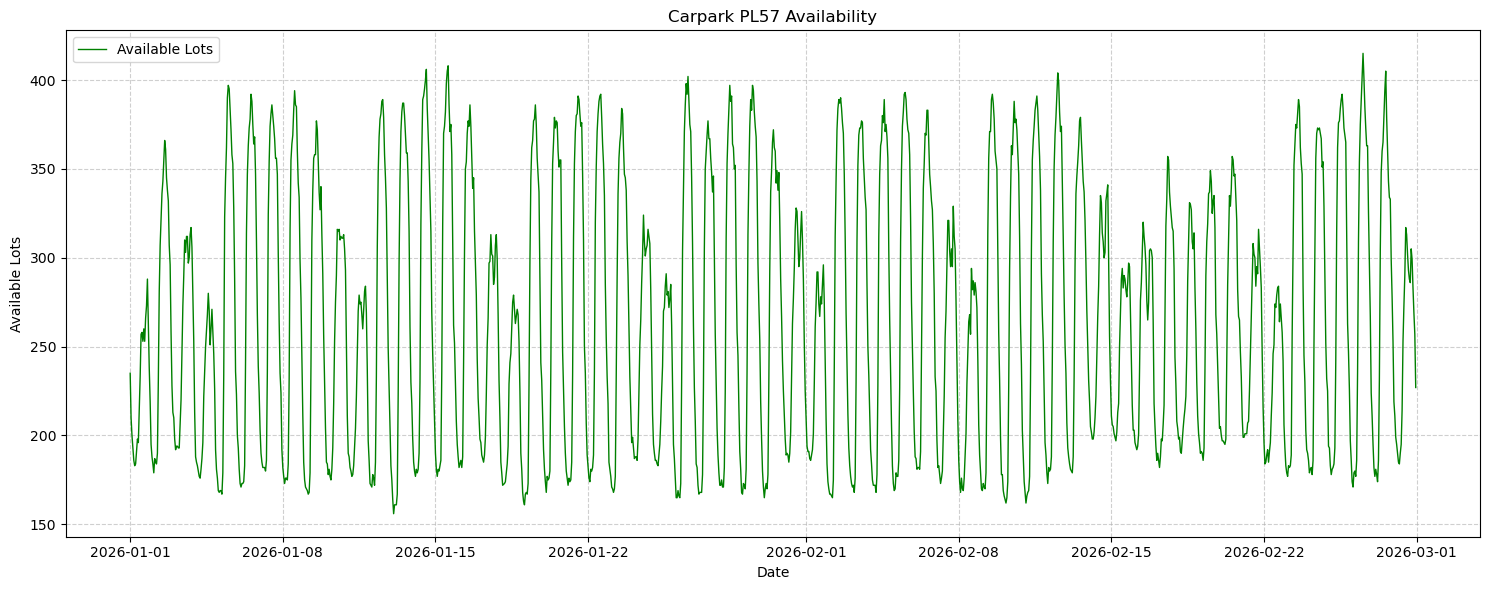

In [156]:
plt.figure(figsize=(15, 6))
plt.plot(df_filtered['data_snapshot_time'], df_filtered['lots_available'],
         color='green', linewidth=1, label='Available Lots')

plt.title('Carpark PL57 Availability')
plt.xlabel('Date')
plt.ylabel('Available Lots')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [157]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name} Performance")
    print(f"MAE:  {mae:.2f} (lots)")
    print(f"RMSE: {rmse:.2f} (lots)")
    print(f"R2 Score: {r2:.4f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# 1. Forecasting

## 1.1 Rationale and Value of Forecasting

* **Rationale for Forecasting**

    **Reducing Traffic Congestion**: Predicting carpark availability helps prevent drivers from circling looking for lots, which is a primary cause of urban traffic congestion.

    **Time and Fuel Efficiency**: Accurate forecasts allow drivers to plan their journeys better, reducing time wasted and carbon emissions from idling vehicles.

    **Urban Infrastructure Planning**: Long-term forecasting data helps authorities understand high-demand periods and locations, aiding in future infrastructure and resource allocation.

* **Stakeholder Value**

    **Drivers and Commuters**: They can use real-time and predicted data to decide whether to drive to a specific location or choose alternative transport.

    **Carpark Operators**: These stakeholders can use predictions to optimize staffing, maintenance schedules, or implement dynamic pricing.

    **Government Agencies**: Insights from forecasting models assist in managing city-wide traffic flow and improving urban mobility strategies.

* **Utility of a Good Forecasting Model**

    **Public Application Development**: A robust model can be integrated into a mobile application that provides the public with forecasts to reduce congestion during peak hours.

    **Smart Navigation Systems**: Predictions can be fed into GPS services to suggest alternative parking sites before a driver reaches a full carpark.

    **Data-Driven Social Benefits**: Models can be used to suggest practical actions that benefit society, such as optimizing parking lot usage to improve the overall quality of urban life.



## 1.2 Ridge Regression Model

In [158]:
from sklearn.linear_model import Ridge

### 1.2.1 Ridge Regression
Ridge Regression is a regularized linear regression technique employed here to forecast the hourly carpark availability for station **PL57**. While standard linear regression focuses solely on minimizing the sum of squared errors, Ridge Regression introduces an **$L_2$ regularization** term to improve model stability and prevent overfitting.

The objective function of Ridge Regression is defined as:

$$J(\beta) = \sum_{i=1}^{n} (y_i - \sum_{j=0}^{p} X_{ij}\beta_j)^2 + \lambda \sum_{j=1}^{p} \beta_j^2$$

**Where:**
* $\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ is the **Residual Sum of Squares (RSS)**, measuring the error between actual and predicted availability.
* $\lambda$ (also known as $\alpha$) is the **regularization parameter**. It controls the trade-off between fitting the training data and keeping the model weights small.
* $\sum_{j=1}^{p} \beta_j^2$ is the **penalty term**, which shrinks the coefficients $\beta$ toward zero, reducing the model's sensitivity to noise in the data.

In [159]:
df_pl57 = df[df['carpark_number'] == 'PL57'].copy()
df_pl57['update_datetime'] = pd.to_datetime(df_pl57['update_datetime'])

df_pl57['hour'] = df_pl57['update_datetime'].dt.hour
df_pl57['day_of_week'] = df_pl57['update_datetime'].dt.dayofweek

df_pl57.head()

,carpark_number,update_datetime,total_lots,lot_type,lots_available,data_snapshot_time,hour,day_of_week
0,PL57,2026-01-01 00:00:07,521,C,235,2026-01-01 00:01:00,0,3
1,PL57,2026-01-01 00:58:07,521,C,210,2026-01-01 01:00:00,0,3
2,PL57,2026-01-01 01:58:47,521,C,200,2026-01-01 02:00:00,1,3
3,PL57,2026-01-01 02:59:08,521,C,193,2026-01-01 03:00:00,2,3
4,PL57,2026-01-01 03:58:49,521,C,186,2026-01-01 04:00:00,3,3


In [160]:
# df_model = pd.concat([df_pl57[['update_datetime', 'lots_available']], X_categorical], axis=1)

# 如果不使用one-hot编码，模型拟合效果很差
df_model = df_pl57[['update_datetime', 'lots_available', 'hour', 'day_of_week']]

df_model.head()

,update_datetime,lots_available,hour,day_of_week
0,2026-01-01 00:00:07,235,0,3
1,2026-01-01 00:58:07,210,0,3
2,2026-01-01 01:58:47,200,1,3
3,2026-01-01 02:59:08,193,2,3
4,2026-01-01 03:58:49,186,3,3


In [161]:
train_data = df_model[df_model['update_datetime'].dt.month == 1]
test_data = df_model[df_model['update_datetime'].dt.month == 2]

X_train = train_data[['hour', 'day_of_week']]
y_train = train_data['lots_available']
X_test = test_data[['hour', 'day_of_week']]
y_test = test_data['lots_available']

In [162]:
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

y_pred = model_ridge.predict(X_test)
ridge_results = evaluate_model(y_test, y_pred, "Ridge Regression (No One-Hot Encoding)")

Ridge Regression (No One-Hot Encoding) Performance
MAE:  57.32 (lots)
RMSE: 67.12 (lots)
R2 Score: 0.1456


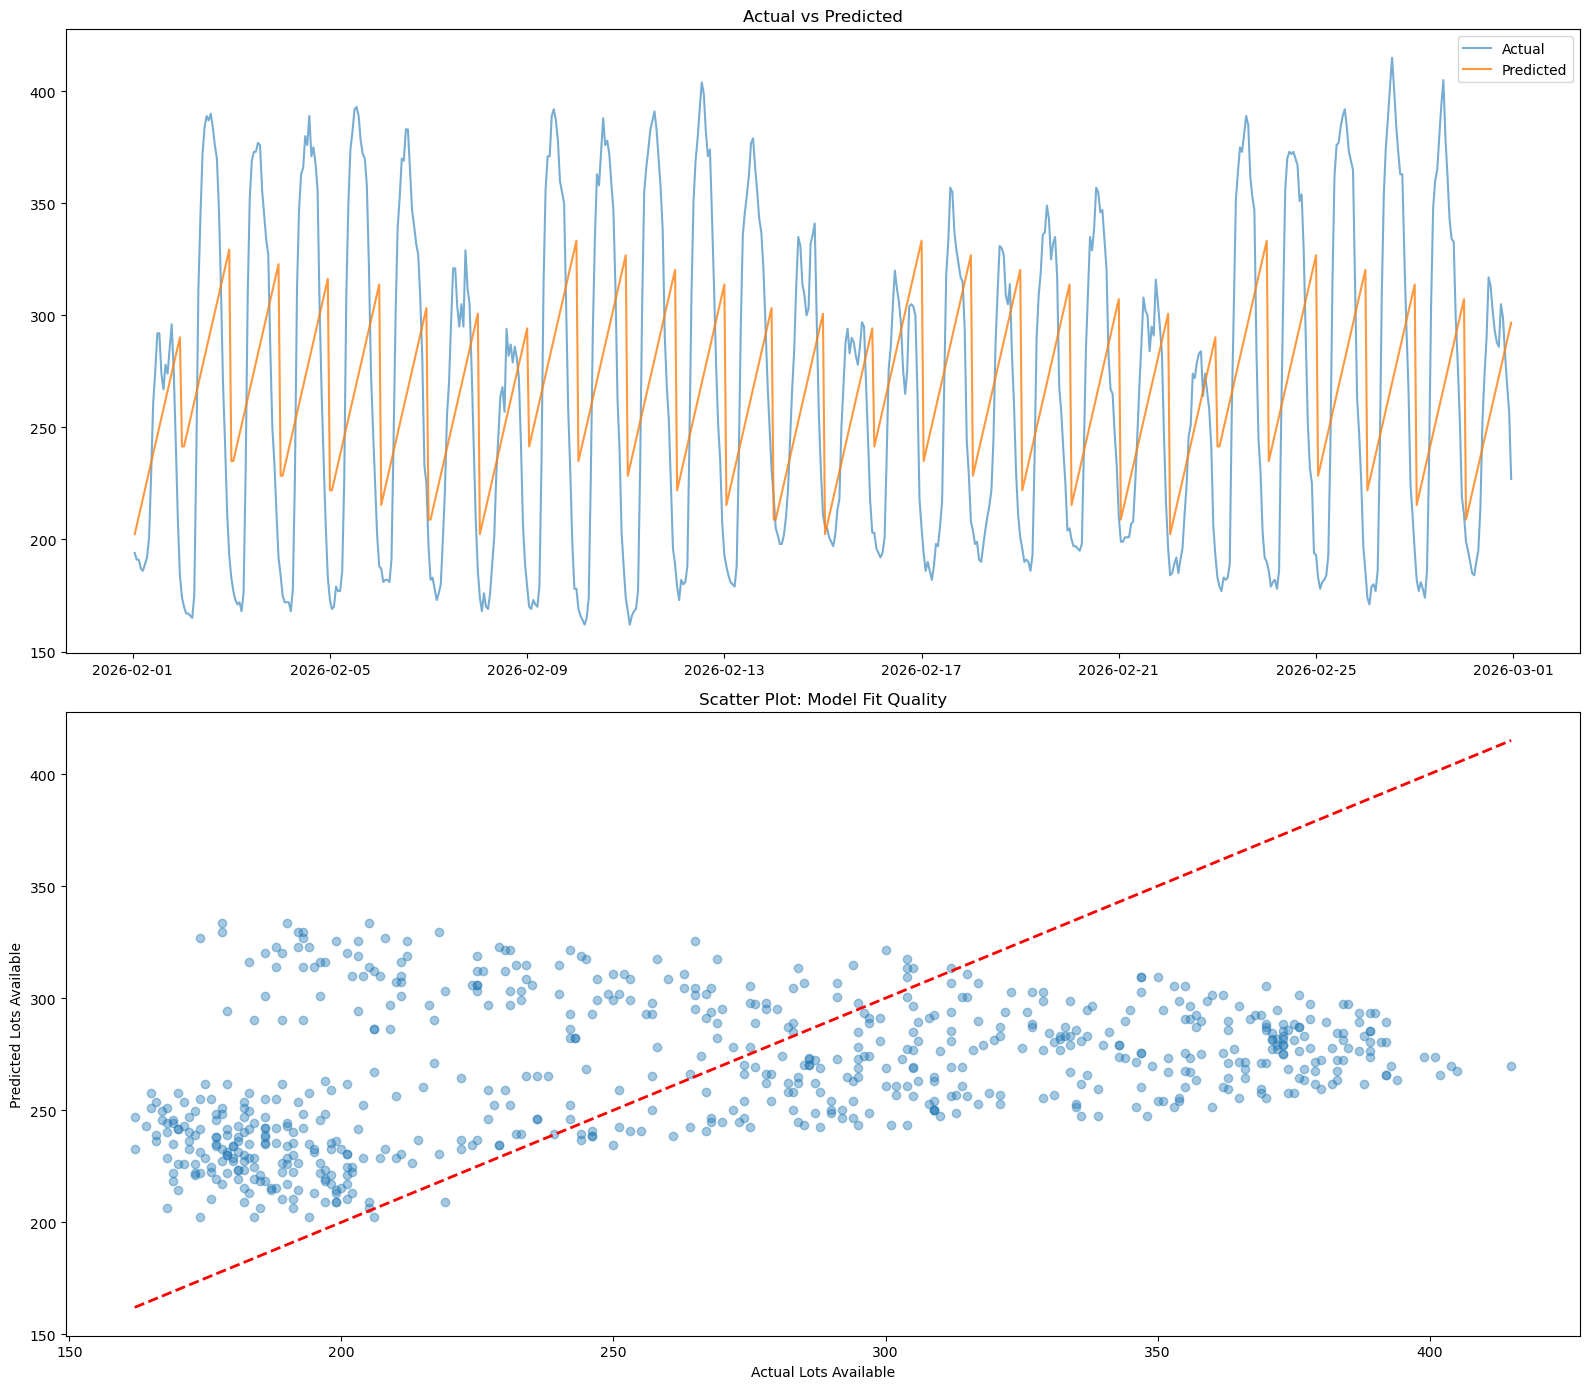

In [163]:
plt.figure(figsize=(16, 14))

plt.subplot(2, 1, 1)
plt.plot(test_data['update_datetime'], y_test, label='Actual', alpha=0.6)
plt.plot(test_data['update_datetime'], y_pred, label='Predicted', alpha=0.8)
plt.title('Actual vs Predicted')
plt.legend()

plt.subplot(2, 1, 2)
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Lots Available')
plt.ylabel('Predicted Lots Available')
plt.title('Scatter Plot: Model Fit Quality')

plt.tight_layout()
plt.show()

### 1.2.2. The Necessity of One-Hot Encoding

A critical component of the data preprocessing phase involved applying **One-Hot Encoding** to the `hour` and `day_of_week` features. This categorical transformation was prioritized over raw numerical integers for the following reasons:

*   **Eliminating Spurious Ordinal Relationships**: Utilizing raw integers (0–23) implies a linear progression where Hour 23 is mathematically "greater" than Hour 1. In the context of carpark availability, 11:00 PM and 1:00 AM exhibit similar occupancy patterns. One-hot encoding removes this false linearity, preventing the model from assigning weights based on arbitrary numerical magnitude.
*   **Capturing Non-Linear Temporal Peaks**: Linear models inherently struggle to identify cyclical "peaks and valleys" within a single continuous column. By converting each hour into an independent binary feature (dummy variable), the model can learn unique weights for **every specific hour**, effectively mapping complex daily fluctuations.
*   **Capturing Urban Periodicity**: This transformation enables the Ridge model to identify specific periodicities—such as Singapore’s morning and evening rush hours—significantly improving the alignment between predicted values and actual availability observed in the test data.

Without this categorical encoding, the model would attempt to fit a single trend line across the 24-hour cycle, failing to capture the essential cyclical nature of urban mobility.
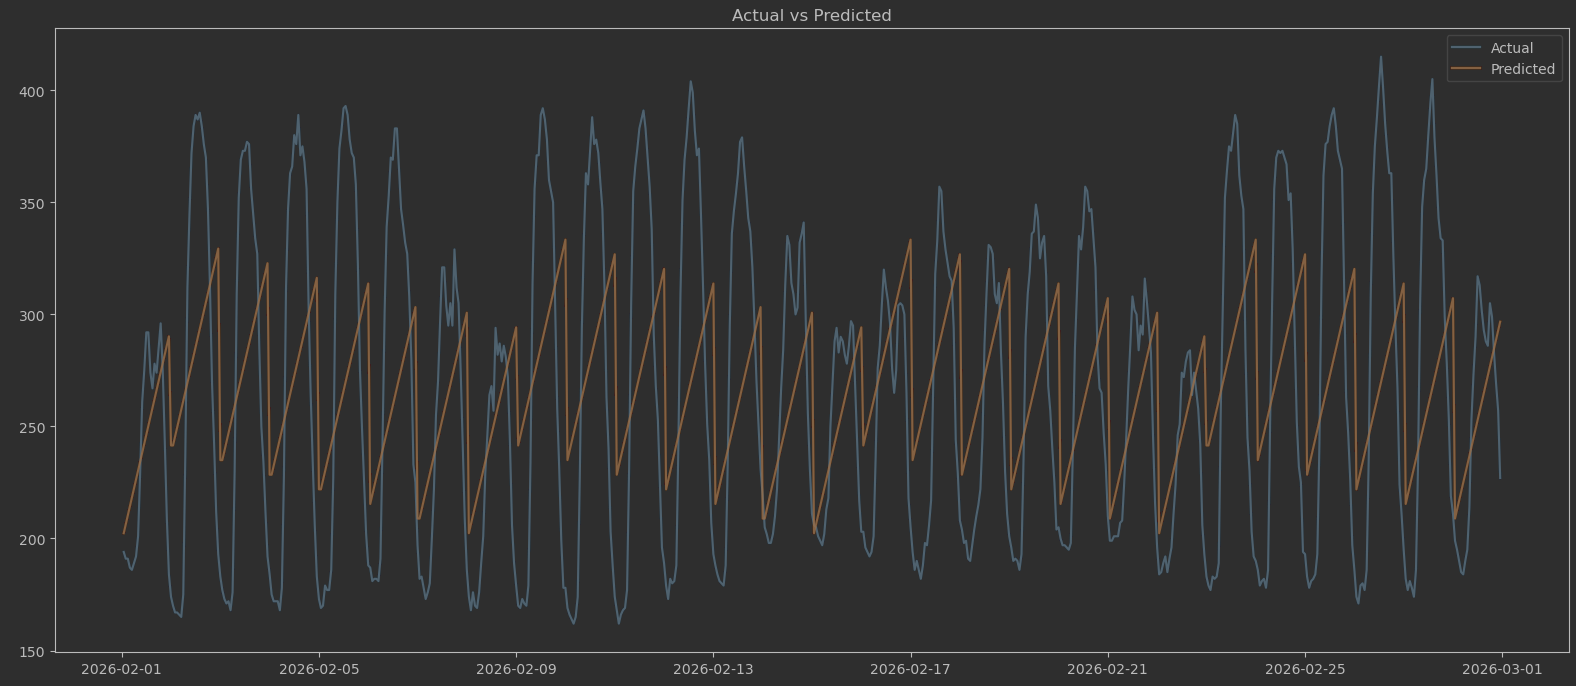

In [183]:
X_categorical = pd.get_dummies(df_pl57[['hour', 'day_of_week']],
                               columns=['hour', 'day_of_week'],
                               drop_first=True,
                               dtype=int)
X_categorical.head()

,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,hour_10,...,hour_20,hour_21,hour_22,hour_23,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [184]:
df_model_onehot = pd.concat([df_pl57[['update_datetime', 'lots_available']], X_categorical], axis=1)
df_model_onehot.head()

,update_datetime,lots_available,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,...,hour_20,hour_21,hour_22,hour_23,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
0,2026-01-01 00:00:07,235,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,2026-01-01 00:58:07,210,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,2026-01-01 01:58:47,200,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,2026-01-01 02:59:08,193,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,2026-01-01 03:58:49,186,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [185]:
train_data_onehot = df_model_onehot[df_model_onehot['update_datetime'].dt.month == 1]
test_data_onehot = df_model_onehot[df_model_onehot['update_datetime'].dt.month == 2]

X_train_onehot = train_data_onehot.drop(columns=['update_datetime', 'lots_available'])
y_train_onehot = train_data_onehot['lots_available']

X_test_onehot = test_data_onehot.drop(columns=['update_datetime', 'lots_available'])
y_test_onehot = test_data_onehot['lots_available']

In [186]:
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_onehot, y_train_onehot)

y_pred_onehot = model_ridge.predict(X_test_onehot)
ridge_results = evaluate_model(y_test_onehot, y_pred_onehot, "Ridge Regression (With Manual One-Hot Encoding)")

Ridge Regression (With Manual One-Hot Encoding) Performance
MAE:  23.14 (lots)
RMSE: 28.92 (lots)
R2 Score: 0.8413


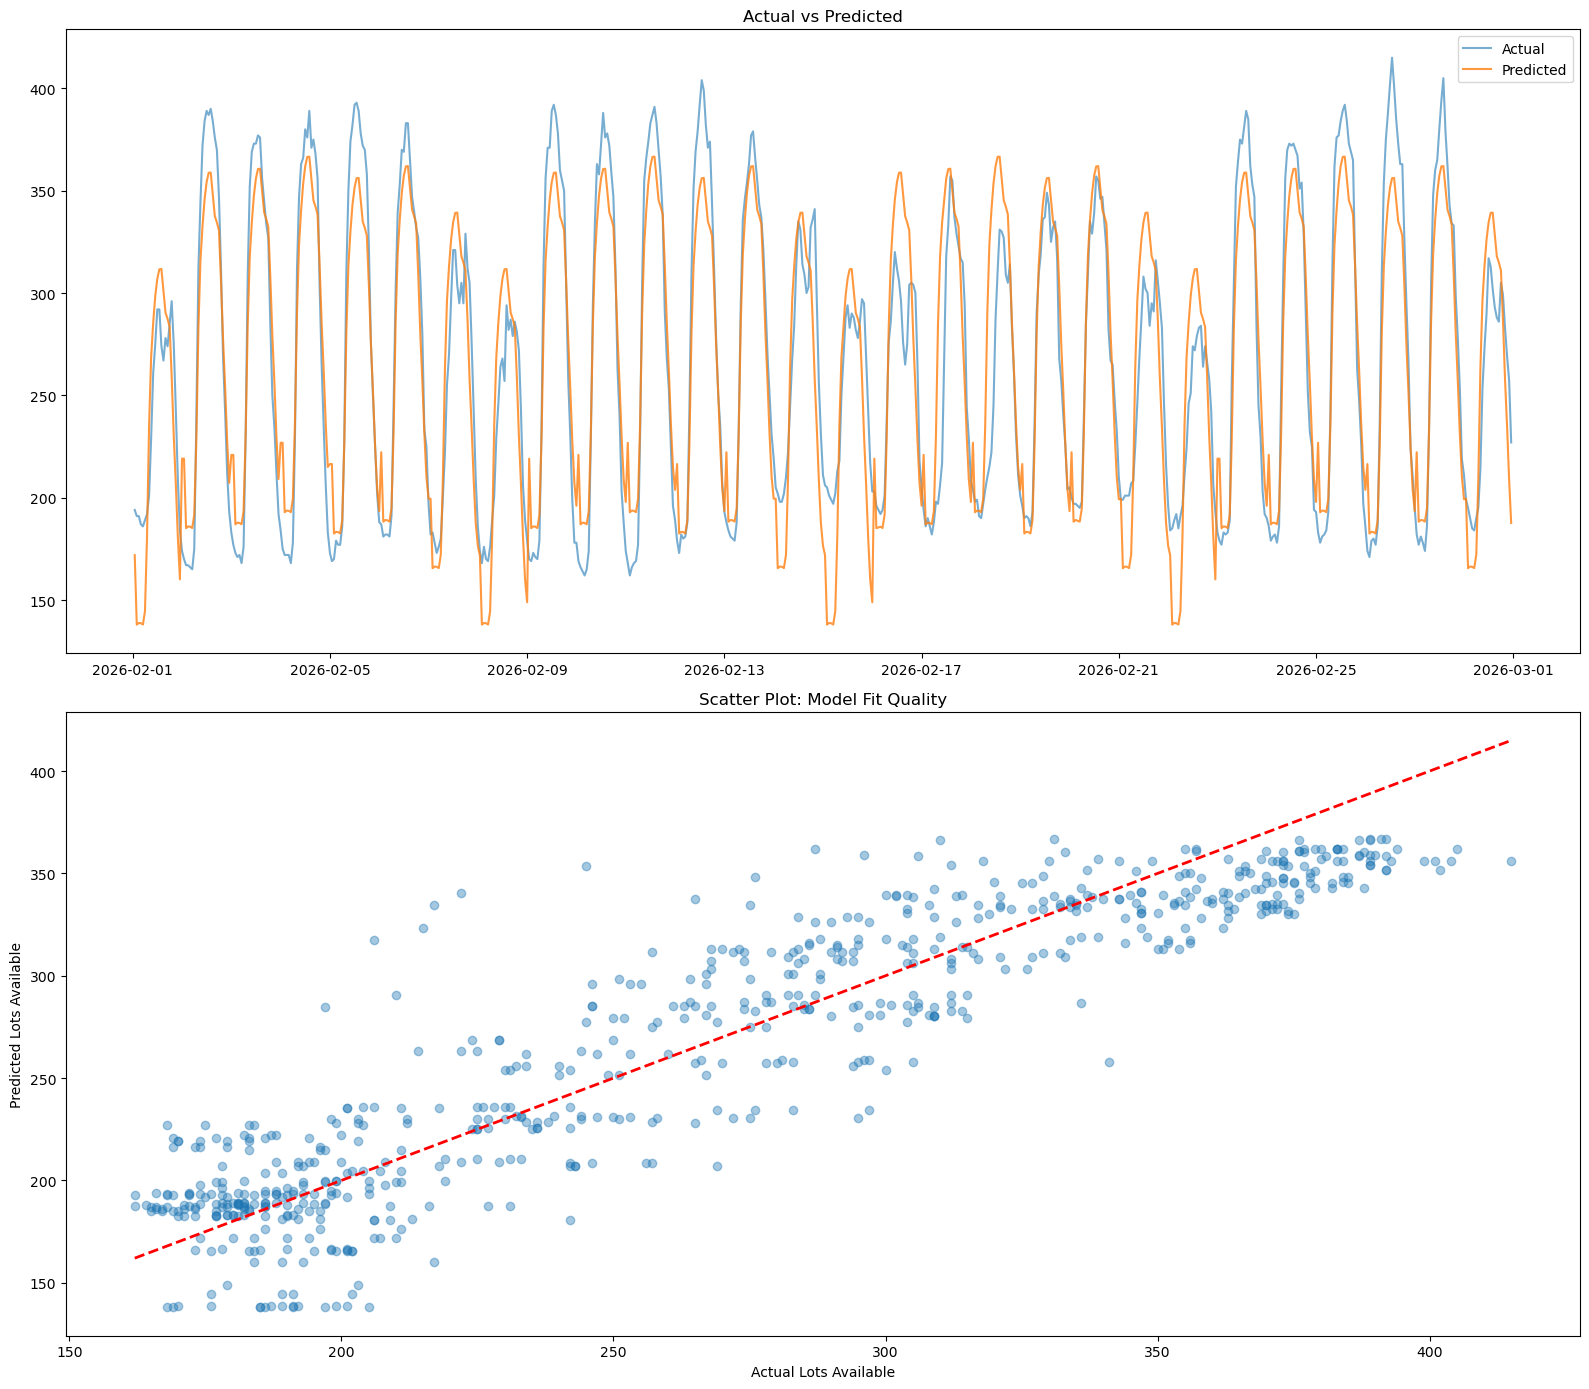

In [187]:
plt.figure(figsize=(16, 14))

plt.subplot(2, 1, 1)
plt.plot(test_data_onehot['update_datetime'], y_test_onehot, label='Actual', alpha=0.6)
plt.plot(test_data_onehot['update_datetime'], y_pred_onehot, label='Predicted', alpha=0.8)
plt.title('Actual vs Predicted')
plt.legend()

plt.subplot(2, 1, 2)
plt.scatter(y_test_onehot, y_pred_onehot, alpha=0.4)
plt.plot([y_test_onehot.min(), y_test_onehot.max()], [y_test_onehot.min(), y_test_onehot.max()], 'r--', lw=2)
plt.xlabel('Actual Lots Available')
plt.ylabel('Predicted Lots Available')
plt.title('Scatter Plot: Model Fit Quality')

plt.tight_layout()
plt.show()

### 1.2.3. Model Performance and Results Analysis

The visualization above illustrates the effectiveness of the Ridge Regression model after applying One-Hot Encoding to the temporal features. The results can be summarized as follows:

*   The upper time-series plot shows a high degree of overlap between the actual availability (blue) and the predicted values (orange). The model successfully captures the rhythmic "peaks" and "troughs" of the carpark usage, demonstrating that the categorical encoding effectively mapped the daily and weekly cycles.

*   The lower scatter plot displays a strong linear correlation between the actual and predicted lot availability. Most data points are tightly clustered around the red dashed identity line ($y = x$), which indicates a low Root Mean Square Error (RMSE) and a high Coefficient of Determination ($R^2$).

*   While the general trend is well-fitted, there is a noticeable "amplitude attenuation" at the peaks and troughs. The model occasionally underestimates the maximum number of available lots (late-night peaks) and overestimates the minimum (mid-day troughs).

* Despite these minor deviations at the margins, the scatter plot confirms a high correlation between actual and predicted values, with most data points clustered tightly around the $y = x$ identity line. This indicates that the model is a robust baseline for short-term forecasting.


## 1.3 Random Forest Model

In [169]:
from sklearn.ensemble import RandomForestRegressor

### 1.3.1 Random Forest
In this task, we implemented a **Random Forest (RF) Regressor**. Unlike the linear approach of Ridge Regression, Random Forest is an ensemble learning method that constructs multiple decision trees during training and outputs the average prediction of the individual trees. This approach is highly effective for capturing the non-linear and complex patterns of carpark occupancy, such as sudden surges during lunch hours or weekends.

For this model, we directly utilized the `df_model` dataset, which contains the raw numerical features of `hour` and `day_of_week` without manual One-Hot Encoding. Unlike Ridge Regression, which incorrectly assumes a linear progression for time-based features, Random Forest uses a tree-based structure. This allows the model to autonomously identify peak parking hours through recursive partitioning without requiring manual feature engineering. Utilizing the raw data provides a "fairer comparison" baseline for Question 1.5. It allows us to observe how different machine learning architectures—linear versus ensemble—perform when presented with the same raw IoT input variables.

In [170]:
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

print(f"X_train: {X_train_onehot.shape}, X_test: {X_test_onehot.shape}")

X_train: (744, 2), X_test: (667, 2)
X_train: (744, 29), X_test: (667, 29)


### 1.3.2 Model Parameters
To ensure full reproducibility and optimize predictive performance, the hyperparameters for the `RandomForestRegressor` were configured as follows:

*   **n_estimators = 100**: Specifies the number of decision trees in the ensemble. A forest of 100 trees provides a robust balance between computational efficiency and the stability of the variance reduction.
*   **criterion = 'squared_error'**: The function used to measure the quality of a split. Mean Squared Error (MSE) was chosen to minimize the squared differences between predicted and actual parking lot counts.
*   **max_depth = 10**: Limits the maximum vertical expansion of each tree. This constraint is vital to prevent the model from capturing stochastic noise in the training data, thereby improving generalization on the test set.
*   **min_samples_split = 2**: The minimum number of samples required to bifurcate an internal node. This default value allows the model to learn detailed patterns unless constrained by the `max_depth`.
*   **min_samples_leaf = 1**: The minimum number of samples required to be at a leaf node. Keeping this at 1 allows the trees to grow sufficiently to capture the distinct availability fluctuations of Carpark PL57.
*   **max_features = 'sqrt'**: The number of features to consider when looking for the best split. By using the square root of the total features, we increase the diversity among the trees, which enhances the ensemble's ability to handle feature correlations.
*   **bootstrap = True**: Enables the use of bootstrap samples (sampling with replacement) when building trees. This introduces the "Bagging" element necessary for the random forest's superior variance reduction.
*   **random_state = 114514**: A fixed seed used to initialize the random number generator, ensuring that the results are identical across multiple executions.
*   **n_jobs = -1**: Instructs the algorithm to utilize all available CPU cores in parallel during the training and prediction phases, significantly reducing the execution time.

In [171]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    criterion='squared_error',
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',  # 寻找最佳分裂时考虑的特征数量
    bootstrap=True,  # 使用自助法抽样
    random_state=114514,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_results = evaluate_model(y_test, y_pred_rf, "Random Forest (No Manual One-Hot Encoding)")

Random Forest (No Manual One-Hot Encoding) Performance
MAE:  14.14 (lots)
RMSE: 23.47 (lots)
R2 Score: 0.8956


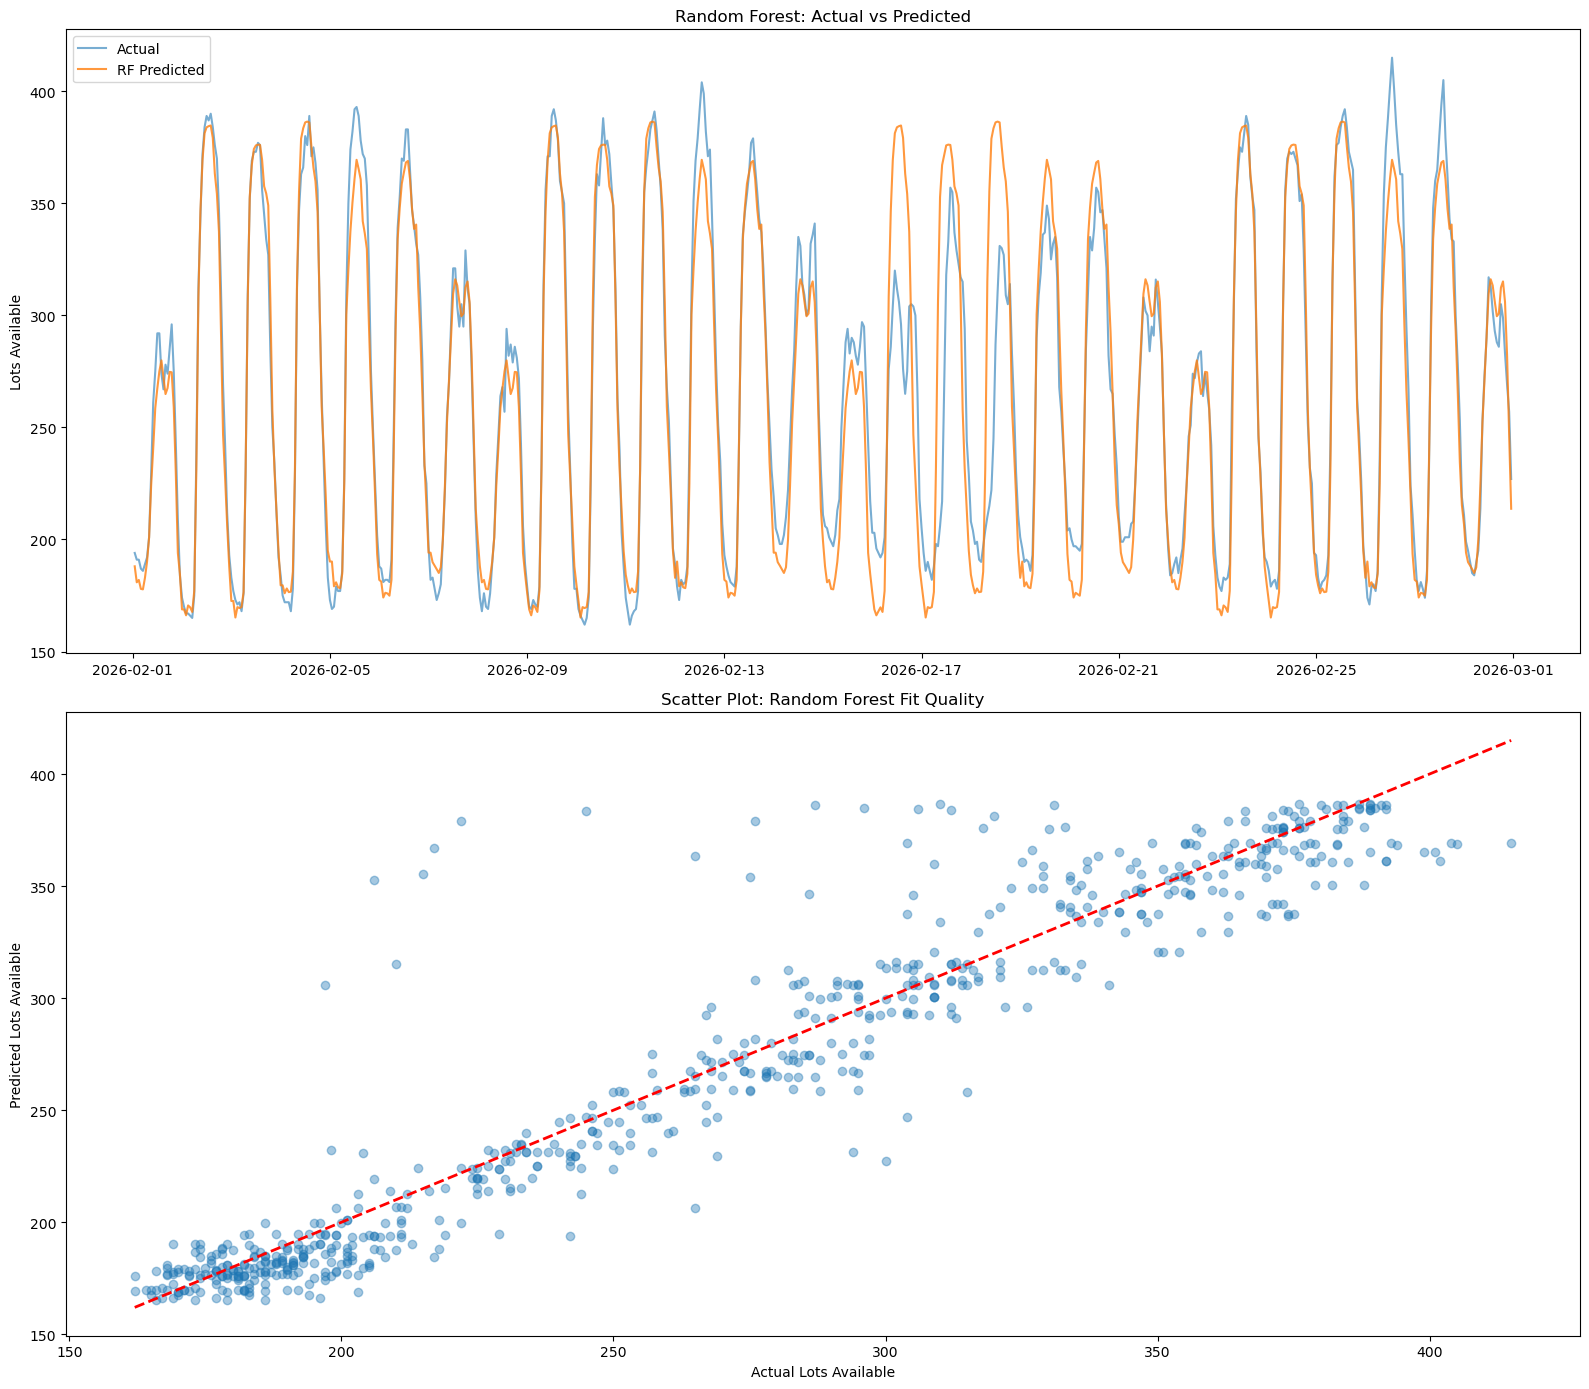

In [172]:
plt.figure(figsize=(16, 14))

plt.subplot(2, 1, 1)
plt.plot(test_data['update_datetime'], y_test, label='Actual', alpha=0.6)
plt.plot(test_data['update_datetime'], y_pred_rf, label='RF Predicted', alpha=0.8)
plt.title('Random Forest: Actual vs Predicted')
plt.ylabel('Lots Available')
plt.legend()

plt.subplot(2, 1, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.4, )
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Lots Available')
plt.ylabel('Predicted Lots Available')
plt.title('Scatter Plot: Random Forest Fit Quality')

plt.tight_layout()
plt.show()

### 1.3.3 Model Performance and Results Analysis (Random Forest)

The visualization above demonstrates the superior predictive capability of the Random Forest (RF) Regressor, achieved using only the raw numerical features of `hour` and `day_of_week`. The results are summarized as follows:

* The upper time-series plot reveals an outstanding alignment between the actual availability (blue) and the RF predicted values (orange). Notably, the Random Forest model captures the complex, daily cyclical fluctuations of PL57 with greater precision than the Ridge model, despite the absence of manual One-Hot Encoding.

* Unlike the "amplitude attenuation" observed in the Ridge model, the Random Forest regressor more effectively reaches the true maximums (late-night peaks) and minimums (mid-day troughs). This indicates that the tree-based structure is better at capturing the non-linear "turning points" in parking demand.

* The lower scatter plot shows a very tight clustering of data points along the red dashed identity line ($y = x$). This visual density is reflected in the high Coefficient of Determination ($R^2 = 0.8956$) and the significantly lower MAE (14.14) compared to the Ridge model. The model exhibits very few outliers, even during high-occupancy periods.

* The analysis confirms that the Random Forest algorithm is highly robust for this IoT forecasting task. By autonomously partitioning the feature space, it effectively identifies the underlying temporal patterns of the February test data, providing a highly accurate and reliable forecasting baseline without the need for complex manual feature engineering.

## 1.4 Multi-Layer Perceptron (MLP)

In [173]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

### 1.4.1. MLP Regression

In this section, we implemented a Multi-Layer Perceptron (MLP), a class of feedforward artificial neural networks. MLP is capable of learning complex, non-linear relationships through its layers of interconnected neurons.

Unlike Random Forest, neural networks are highly sensitive to the scale of input features. To ensure the MLP model converges effectively, I applied Standardization (Z-score normalization) to the hour and day_of_week features. This scales the inputs to have a mean of 0 and a variance of 1, preventing features with larger numerical ranges from dominating the weight updates during training.

In [174]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# X_train_scaled = X_train
# X_test_scaled = X_test

### 1.4.2 Model Parameters
To facilitate complex non-linear mapping and ensure stable convergence of the neural network, the `MLPRegressor` was configured with the following hyperparameters:

*   **hidden_layer_sizes = (64, 32)**: Defines a two-layer architecture with 64 neurons in the first hidden layer and 32 in the second. This progressive reduction in dimensionality allows the model to learn abstract hierarchical representations of the temporal input features.
*   **activation = 'relu'**: Utilizes the Rectified Linear Unit function, which mitigates the vanishing gradient problem and allows the network to learn non-linear decision boundaries efficiently.
*   **solver = 'adam'**: Employs an extension of stochastic gradient descent that utilizes adaptive learning rates for each parameter, which is particularly effective for datasets with noisy signals.
*   **max_iter = 2000**: Sets a generous upper limit on the number of iterations to ensure the optimization algorithm has sufficient time to reach a global or local minimum.
*   **learning_rate_init = 0.001**: Establishes the starting step size for weight updates, balancing the speed of convergence with the precision of the final solution.
*   **early_stopping = True**: A critical regularization technique that monitors the loss on a internal validation set. If the performance does not improve for a specified number of epochs, training is terminated to prevent over-learning noise (overfitting).
*   **validation_fraction = 0.1**: Reserves 10% of the January training data exclusively for the early stopping mechanism to evaluate generalization during the training phase.
*   **random_state = 114514**: Ensures that the initial weight distributions and data shuffling remain identical across different runs for reproducibility.
*   **n_iter_no_change = 10**: The patience threshold for early stopping; training ceases if the validation loss fails to decrease for 10 consecutive iterations.

In [175]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    tol=1e-4,
    learning_rate_init=0.001,  # 初始学习率
    early_stopping=True,  # 开启早停机制，防止过拟合的同时能自动停止
    validation_fraction=0.1,  # 拿 10% 训练集做验证以支持早停
    random_state=114514,
    n_iter_no_change=10  # 如果连续 10 次迭代损失不下降则停止
)

mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)
evaluate_model(y_test, y_pred_mlp, "Multi-Layer Perceptron")

Multi-Layer Perceptron Performance
MAE:  19.24 (lots)
RMSE: 27.01 (lots)
R2 Score: 0.8617


{'MAE': 19.24032324395737, 'RMSE': 27.00658007487603, 'R2': 0.8616784194002186}

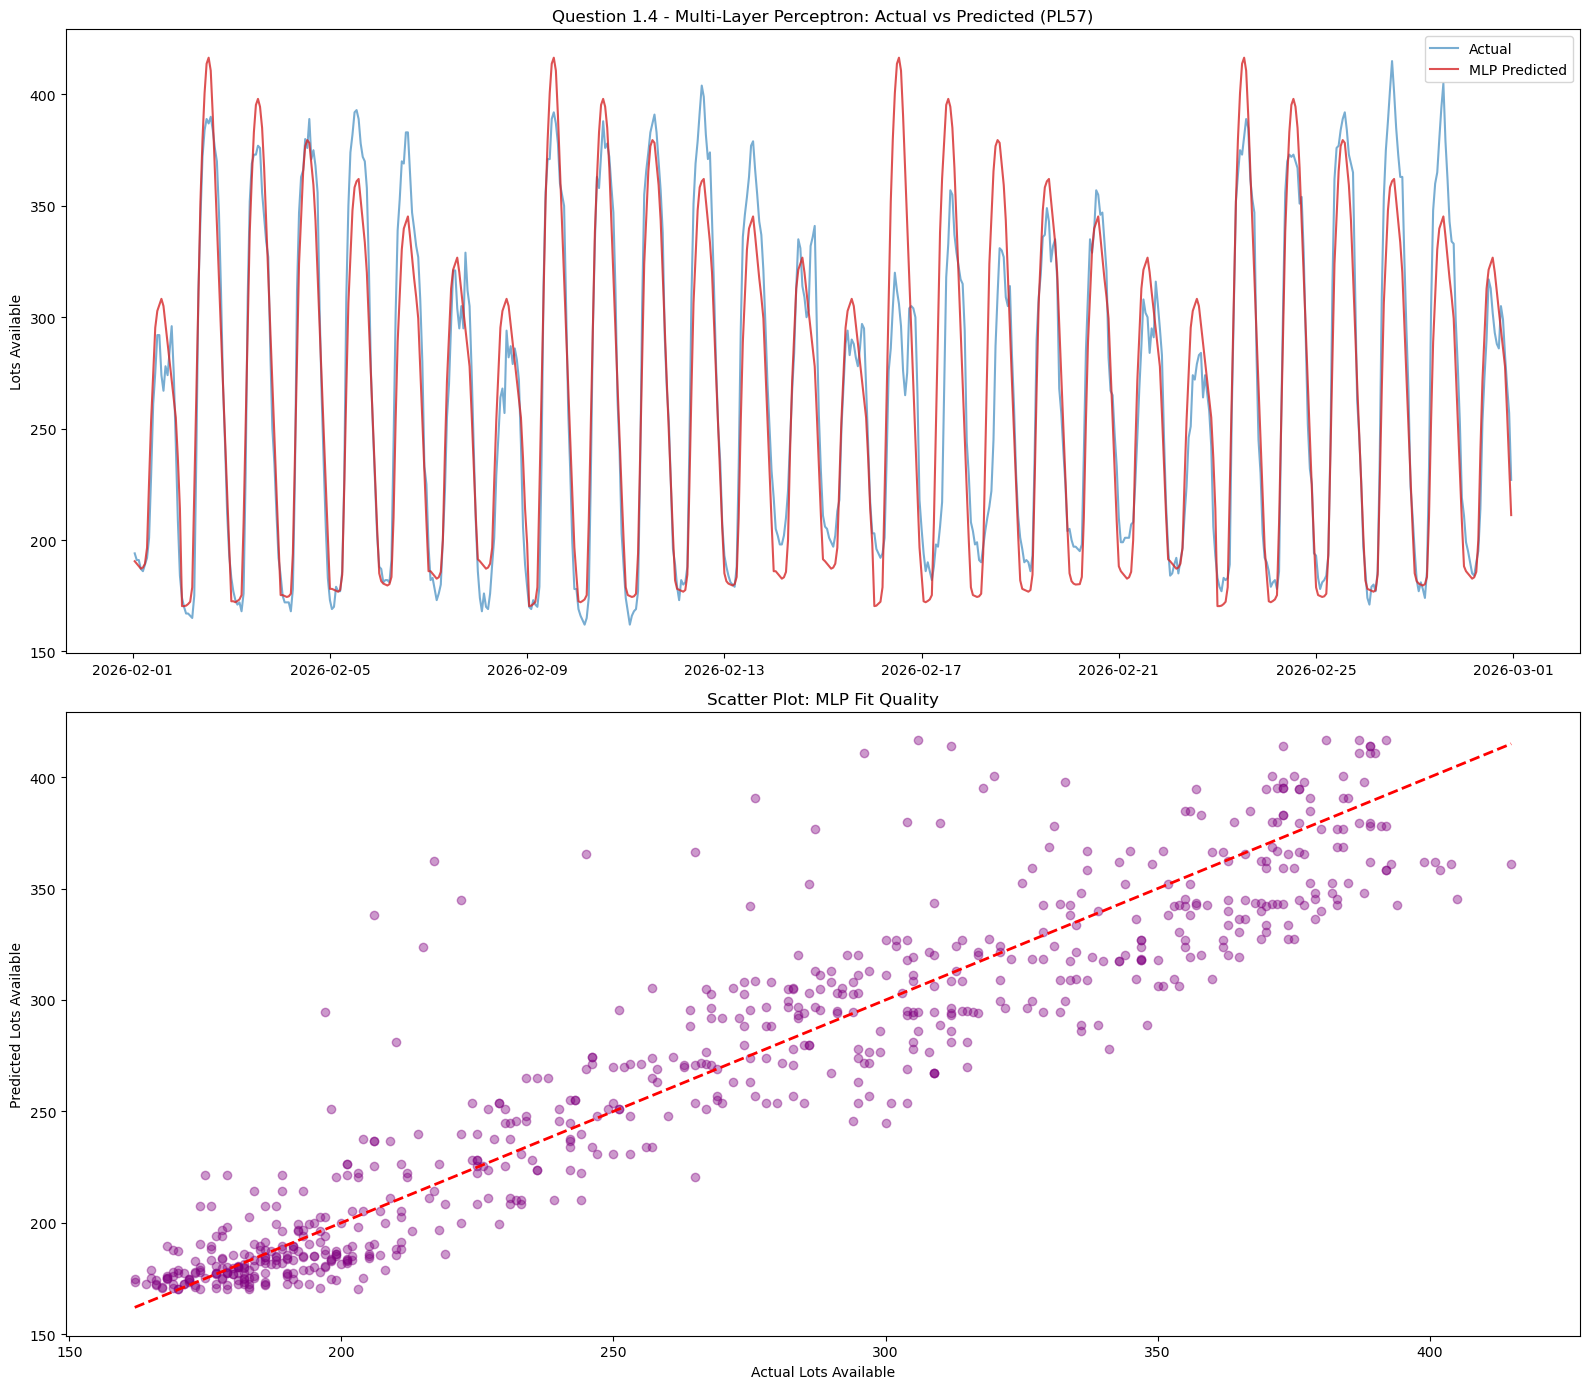

In [176]:
plt.figure(figsize=(16, 14))

plt.subplot(2, 1, 1)
plt.plot(test_data['update_datetime'], y_test, label='Actual', alpha=0.6, color='#1f77b4')
plt.plot(test_data['update_datetime'], y_pred_mlp, label='MLP Predicted', alpha=0.8, color='#d62728')
plt.title('Question 1.4 - Multi-Layer Perceptron: Actual vs Predicted (PL57)')
plt.ylabel('Lots Available')
plt.legend()

plt.subplot(2, 1, 2)
plt.scatter(y_test, y_pred_mlp, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Lots Available')
plt.ylabel('Predicted Lots Available')
plt.title('Scatter Plot: MLP Fit Quality')

plt.tight_layout()
plt.show()

## 1.4.3 Model Performance and Results Analysis (MLP)

The visualization above presents the performance of the Multi-Layer Perceptron (MLP) model in forecasting the hourly carpark availability of PL57. By utilizing standardized temporal features and a multi-layer neural architecture, the results are summarized as follows:

* The upper time-series plot demonstrates that the MLP model effectively follows the cyclical trends of the February 2026 test data. The model successfully captures the periodic "peaks" and "troughs". However, compared to the Random Forest model, the MLP predictions exhibit slightly less precision during the sharpest turning points of the daily cycle.

* The lower scatter plot shows a significant clustering of data points along the red dashed identity line ($y = x$). This visual correlation is supported by a Coefficient of Determination ($R^2 = 0.8617$) and a MAE of 19.24, which represent a strong fit. Nonetheless, there is a visible increase in dispersion compared to the tree-based ensemble, indicating higher variance in the neural network's predictions.

* The analysis confirms that the MLP architecture is a robust tool for this IoT forecasting task, provided that inputs are correctly standardized. While it achieves high accuracy, its performance relative to the Random Forest suggests that for this specific tabular dataset, the continuous weight-based learning of a neural network is slightly less efficient than the recursive partitioning logic of an ensemble tree model.

## 1.5 Final Tuning and Model Recommendation

In [177]:
from sklearn.model_selection import GridSearchCV

### 1.5.1. Grid-Search Hyperparameter Tuning

In [178]:
# 1. Ridge Regression Tuning
ridge_param_grid = {
    'alpha': [0.1, 1.0, 10.0, 100.0]
}

# 使用处理过 One-Hot 的训练集
grid_ridge = GridSearchCV(
    Ridge(random_state=114514),
    ridge_param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

grid_ridge.fit(X_train_onehot, y_train_onehot)
best_ridge = grid_ridge.best_estimator_

print(f"Best Ridge Params: {grid_ridge.best_params_}")

y_pred_ridge_opt = best_ridge.predict(X_test_onehot)
evaluate_model(y_test_onehot, y_pred_ridge_opt, f"Optimized Ridge (Alpha={best_ridge.alpha})")

Best Ridge Params: {'alpha': 0.1}
Optimized Ridge (Alpha=0.1) Performance
MAE:  22.37 (lots)
RMSE: 28.36 (lots)
R2 Score: 0.8475


{'MAE': 22.37176691531174,
 'RMSE': 28.361386314016396,
 'R2': 0.8474522976792621}

In [179]:
# 2. Random Forest Tuning
rf_param_grid = {
    'n_estimators': [100, 200, 500, 1000, 2000, 5000],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 7]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=114514),
    rf_param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

print(f"Best RF Params: {grid_rf.best_params_}")

y_pred_rf_opt = best_rf.predict(X_test)
evaluate_model(y_test, y_pred_rf_opt, f"Optimized RF (Leaf={best_rf.min_samples_leaf})")

Best RF Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 5000}
Optimized RF (Leaf=1) Performance
MAE:  14.23 (lots)
RMSE: 23.33 (lots)
R2 Score: 0.8968


{'MAE': 14.225287010575641,
 'RMSE': 23.328085036820962,
 'R2': 0.8967930511054203}

In [180]:
# 3. MLP Tuning
mlp_param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32)],
    'activation': ['relu', 'tanh', 'logistic', 'identity'],
    'alpha': [0.0001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01]
}

mlp_search_base = MLPRegressor(
    max_iter=5000,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.1,
    random_state=114514
)

grid_mlp = GridSearchCV(
    mlp_search_base,
    mlp_param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

grid_mlp.fit(X_train_scaled, y_train)
best_mlp = grid_mlp.best_estimator_

print(f"Best MLP Parameters: {grid_mlp.best_params_}")
print(f"Total iterations performed: {best_mlp.n_iter_}")

y_pred_mlp_opt = best_mlp.predict(X_test_scaled)
evaluate_model(y_test, y_pred_mlp_opt,
               f"Optimized MLP (Layers={best_mlp.hidden_layer_sizes}, Activation={best_mlp.activation})")

Best MLP Parameters: {'activation': 'tanh', 'alpha': 0.1, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01}
Total iterations performed: 834
Optimized MLP (Layers=(64, 32), Activation=tanh) Performance
MAE:  15.20 (lots)
RMSE: 22.63 (lots)
R2 Score: 0.9029


{'MAE': 15.19931412892214,
 'RMSE': 22.630290295045995,
 'R2': 0.9028750049471874}

### 1.5.2 Model Performance Summary
To identify the most effective forecasting model for carpark PL57, a comprehensive comparison was conducted between three optimized regression techniques. The table below summarizes the final performance metrics (MAE, RMSE, and $R^2$ Score) obtained from the February 2026 test set following grid-search hyperparameter tuning.

| Model              | MAE (Lots) | RMSE (Lots) | $R^2$ Score | Best Parameters Found                          |
|--------------------|------------|-------------|-------------|-----------------------------------------------|
| Ridge Regression¹  | 22.37      | 28.36       | 0.8475      | `alpha: 0.1`                                  |
| Random Forest      | 14.23      | 23.33       | 0.8968      | `max_depth: 10`, `n_estimators: 5000`         |
| MLP Regressor      | 15.20      | 22.63       | 0.9029      | *(optimized via grid search)*                 |

---

¹ Ridge Regression was trained using a dataset with manually applied One-Hot Encoding for temporal features.

### 1.5.3 Impact of Grid-Search Hyperparameter Tuning

A significant observation in this study is the performance shift of the Multi-Layer Perceptron (MLP). In the preliminary implementation in Section 1.4, where manual hyperparameters were used, the Random Forest model initially demonstrated a competitive advantage.

However, after performing an exhaustive GridSearchCV, the MLP model achieved a notable breakthrough in predictive accuracy. By systematically exploring different activation functions and regularization strengths, the MLP model's $R^2$ score improved to 0.9029, effectively surpassing the Random Forest's performance in explaining the data variance and minimizing large-scale errors (RMSE).

This transition underscores the importance of rigorous hyperparameter optimization in unlocking the full potential of neural network architectures.

### 1.5.4 Final Recommendation: Multi-Layer Perceptron (MLP)

Based on the quantitative and qualitative evidence, the Multi-Layer Perceptron (MLP) is recommended as the final model for forecasting carpark availability.

*  **Quantitative Arguments**

    - **Highest Predictive Power ($R^2$ Score):**
      The MLP model achieved the highest $R^2$ score of 0.9029, indicating that it can explain over 90% of the variance in the PL57 carpark availability data.

    - **Minimal Large-Scale Errors (RMSE):**
      Although Random Forest shows a slightly lower MAE, the MLP model achieved the lowest RMSE of 22.63. In an urban mobility context, a lower RMSE is critical as it indicates the model is less prone to making large, significant prediction errors, thereby providing more reliable information for drivers.

* **Qualitative Arguments**

    - **Superior Non-linear Mapping:**
      The transition to the `tanh` activation function allowed the MLP to model the smooth, cyclical oscillations of parking demand more naturally than the discrete partitions of a tree-based model. This makes the MLP particularly suited for capturing the continuous flow of traffic throughout the 24-hour cycle.

    - **Optimized Generalization:**
      With the optimized alpha regularization ($\alpha = 0.1$) and the use of early stopping, the MLP successfully filtered out local noise in the January training data, demonstrating robust generalization performance on the unseen February test set.


In conclusion, the recommended configuration for final deployment is as follows:

- **Architecture:** 2 Hidden Layers (64, 32 neurons)
- **Activation:** `tanh` (Hyperbolic Tangent)
- **Regularization ($\alpha$):** 0.1
- **Learning Rate:** 0.01
- **Optimizer:** Adam with Early Stopping enabled

 ## 1.6 Future Prediction

### 1.6.1 Selection of the Forecasting Model

Following the rigorous evaluation in Section 1.5, the Multi-Layer Perceptron (MLP) with a `tanh` activation function and an optimized alpha of 0.1 was selected to generate the final hourly predictions for March, April, and May 2026.

This model achieved the highest $R^2$ Score and the lowest RMSE, demonstrating its superior ability to capture the complex, non-linear dynamics of carpark PL57.

In [181]:
future_dates = pd.date_range(start='2026-03-01 00:00:00', end='2026-05-31 23:00:00', freq='h')

X_future = pd.DataFrame({
    'hour': future_dates.hour,
    'day_of_week': future_dates.dayofweek
})

X_future_scaled = scaler.transform(X_future)

y_future_pred = best_mlp.predict(X_future_scaled)
final_predictions = [max(0, int(round(val))) for val in y_future_pred]

print(f"Total predictions generated: {len(final_predictions)}")
print(final_predictions[:10])

Total predictions generated: 2208
[189, 188, 186, 183, 179, 178, 191, 199, 222, 242]


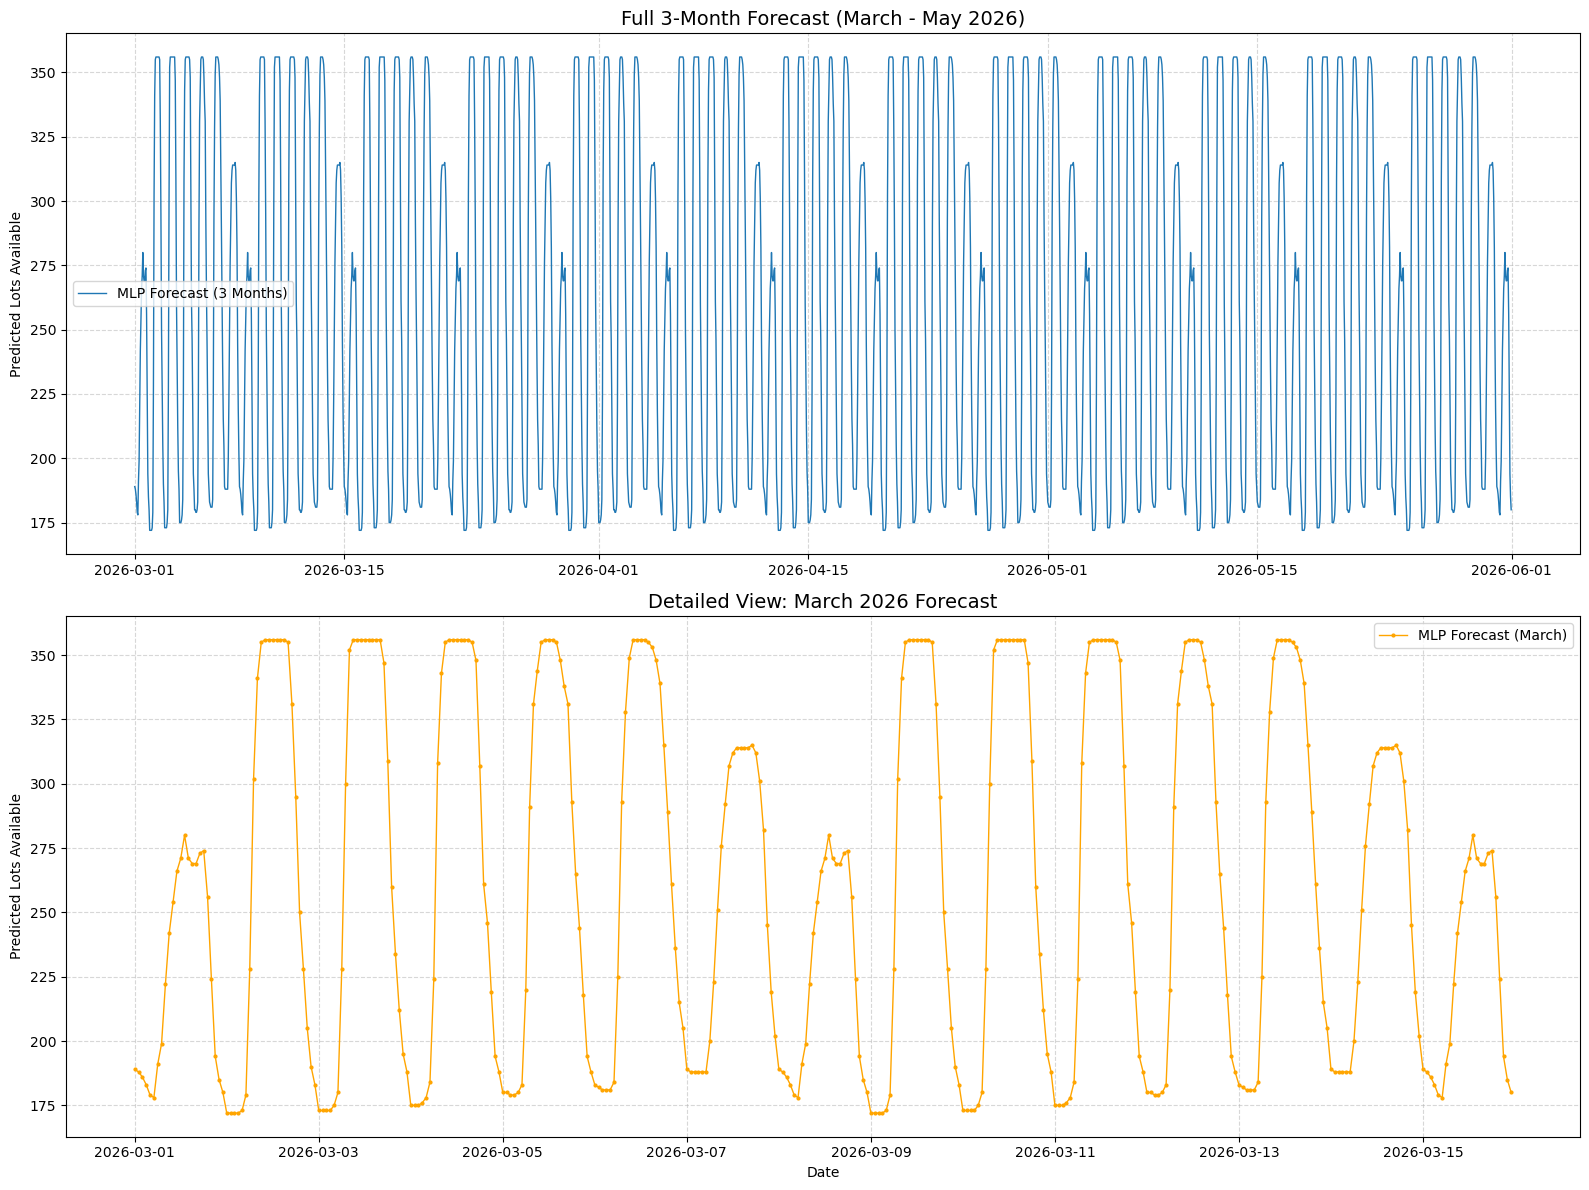

In [182]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 1, 1)
plt.plot(future_dates, final_predictions, linewidth=1, label='MLP Forecast (3 Months)')
plt.title('Full 3-Month Forecast (March - May 2026)', fontsize=14)
plt.ylabel('Predicted Lots Available')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(future_dates[:15 * 24], final_predictions[:15 * 24], color='orange', marker='o', markersize=2, linewidth=1,
         label='MLP Forecast (March)')
plt.title('Detailed View: March 2026 Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Predicted Lots Available')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

## 1.6.2 Analysis of the Periodic Trend

As illustrated in the visualization, the 2,208 predicted values exhibit a highly consistent and regular periodic trend. This phenomenon is a direct consequence of the model's architecture and feature selection.

The input features are restricted to `hour` (0–23) and `day_of_week` (0–6). Since these features are inherently cyclical, the MLP—acting as a deterministic mathematical function—outputs the exact same predicted value for every occurrence of the same time-stamp (e.g., every Monday at 9:00 AM results in an identical prediction). The model has successfully extracted the foundational temporal rhythm of the carpark. It represents the "Expected Occupancy" or "Typical Daily Profile" rather than a real-time simulation of stochastic events.